# Module 1 Pre-Fire Landscape Conditions
**Region:** Cache la Poudre watershed, Larimer County, CO pre-2020 Cameron Peak Fire

Builds vegetation, fuel, and drought-stress indicators from Sentinel-2-style
imagery for a scene dated just before the fire's June 2020 ignition, to
establish a pre-fire baseline. All data in this notebook is synthetic demo
data (see toolkit README) run through the real indicator formulas.

In [1]:
import matplotlib.pyplot as plt
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox
print(REGION.name)
print(REGION.description)
print("bbox:", BBOX)

Cache la Poudre Watershed — Cameron Peak Burn Scar
Upper Cache la Poudre River watershed, Larimer County, Colorado, spanning the area burned by the 2020 Cameron Peak Fire down to the river's exit onto the Front Range near Fort Collins.
bbox: (-105.85, 40.55, -105.45, 40.85)


## Pull a pre-fire optical scene and compute NDVI

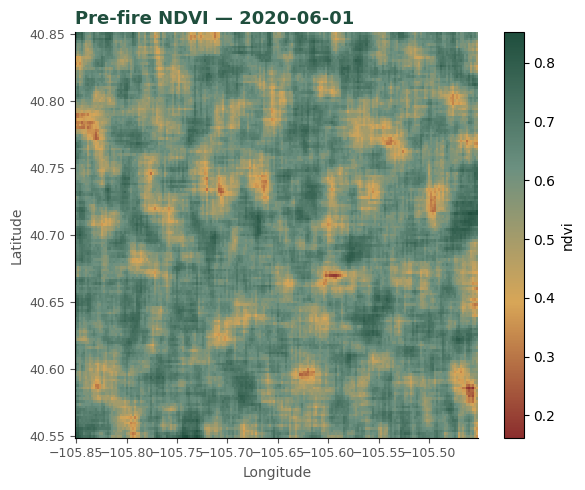

In [2]:
pre_fire_date = "2020-06-01"  # weeks before Cameron Peak ignition (Aug 13, 2020)
pre_scene = data_access.get_optical_scene(BBOX, pre_fire_date, seed=100)
pre_ndvi = indicators.ndvi(pre_scene)

fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(pre_ndvi, title=f"Pre-fire NDVI — {pre_fire_date}", ax=ax)
plt.tight_layout()
plt.savefig("../outputs/01_pre_fire_ndvi.png", dpi=150)
plt.show()

## Terrain and drought-proxy context

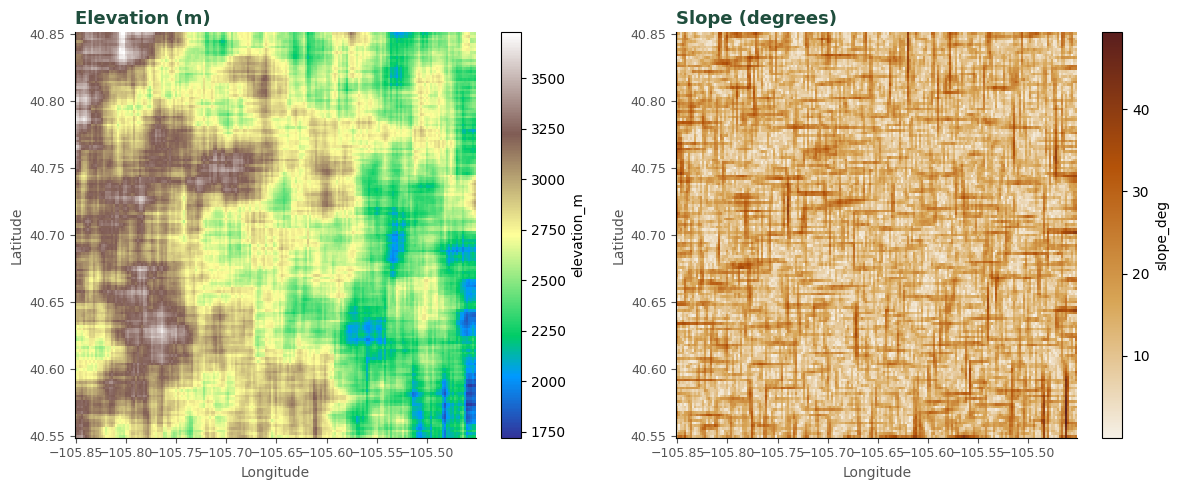

In [3]:
terrain = data_access.get_terrain(BBOX)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(terrain["elevation_m"], title="Elevation (m)", ax=axes[0], cmap="terrain")
viz.plot_raster(terrain["slope_deg"], title="Slope (degrees)", ax=axes[1], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/01_terrain.png", dpi=150)
plt.show()

## Fuel-load proxy

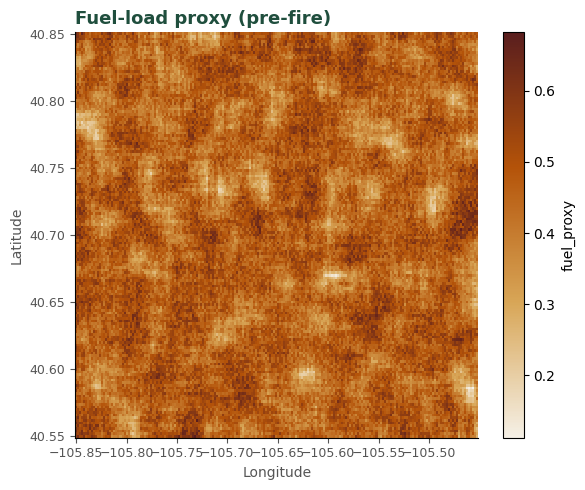

Mean fuel proxy: 0.458
Area-fraction high fuel (>0.6): 1.7%


In [4]:
import numpy as np
# Simple synthetic drought-stress layer (0-1) standing in for a real SPI/PDSI product
rng = np.random.default_rng(42)
drought_stress = pre_ndvi.copy()
drought_stress.values = rng.uniform(0.3, 0.7, pre_ndvi.shape)

fuel = indicators.fuel_proxy(pre_ndvi, drought_stress)
fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(fuel, title="Fuel-load proxy (pre-fire)", ax=ax, cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/01_fuel_proxy.png", dpi=150)
plt.show()

print(f"Mean fuel proxy: {float(fuel.mean()):.3f}")
print(f"Area-fraction high fuel (>0.6): {float((fuel > 0.6).mean()):.1%}")

## Summary

This baseline includes NDVI, terrain, and a fuel-load proxy and is what Module 2
compares against once the fire has burned through, and what Module 3 tracks
recovery against. In a live deployment this pulls a real Sentinel-2 scene
from the weeks before ignition; here it demonstrates the same pipeline on
synthetic data.
